Clasificación de Mortalidad Hospitalaria
Machine Learning Supervisado ***
###Omar Dario Diaz H.

In [ ]:
!pip install scikeras

In [ ]:
import os
import pandas as pd
import numpy as np
from google.colab import drive
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, make_scorer
from sklearn.model_selection import StratifiedKFold, GridSearchCV, RandomizedSearchCV
from scipy.stats import randint, loguniform
from tensorflow import keras
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.svm import LinearSVC
from tqdm.notebook import tqdm
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from collections import Counter
from imblearn.under_sampling import RandomUnderSampler
from imblearn.ensemble import RUSBoostClassifier, BalancedRandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve, auc
from itertools import cycle

Inicialmente hacemos un cargue de los datos desde googledrive, sobre el dataset compartido.

In [ ]:
drive.mount('/content/drive', force_remount=True)

#Ruta Local Omar B.
os.chdir('/content/drive/MyDrive/ColabNotebooks/MaestriaUniandesColabs/ML_Supervisado/Examen_Final')

Mounted at /content/drive


In [ ]:
data_cruda = pd.read_csv('mortalidad_data_train.csv')
data_cruda.head()

,Unnamed: 0,age,sex,dzgroup,dzclass,num.co,scoma,avtisst,race,sps,aps,surv2m,surv6m,hday,diabetes,dementia,ca,dnr,dnrday,meanbp,hrt,resp,temp,crea,sod,adlsc,hospdead
0,0,62.84998,male,Lung Cancer,Cancer,0,0.0,7.000000,other,33.898438,20.0,0.262939,0.036995,1,0,0,metastatic,no dnr,5.0,97.0,69.0,22.0,36.00000,1.199951,141.0,7.0,0
1,1,60.33899,female,Cirrhosis,COPD/CHF/Cirrhosis,2,44.0,29.000000,white,52.695312,74.0,0.001000,0.000000,3,0,0,no,NaN,NaN,43.0,112.0,34.0,34.59375,5.500000,132.0,1.0,1
2,2,52.74698,female,Cirrhosis,COPD/CHF/Cirrhosis,2,0.0,13.000000,white,20.500000,45.0,0.790894,0.664917,4,0,0,no,no dnr,17.0,70.0,88.0,28.0,37.39844,2.000000,134.0,0.0,0
3,3,42.38498,female,Lung Cancer,Cancer,2,0.0,7.000000,white,20.097656,19.0,0.698975,0.411987,1,0,0,metastatic,no dnr,3.0,75.0,88.0,32.0,35.00000,0.799927,139.0,0.0,0
4,4,79.88495,female,ARF/MOSF w/Sepsis,ARF/MOSF,1,26.0,18.666656,white,23.500000,30.0,0.634888,0.532959,3,0,0,no,no dnr,16.0,59.0,112.0,20.0,37.89844,0.799927,143.0,2.0,0


## ***Adecuación*** y preprocesamiento de los datos.

# ***Variables y Tipos de Datos***
El dataset presenta una diversidad de tipos de datos, algo común en muchos estudios clínicos. Se distinguen claramente variables numéricas (como age, aps, saps) y variables categóricas. La mayoría de estas variables categóricas son de naturaleza nominal, lo cual requerirá la aplicación de una codificación adecuada (por ejemplo, one-hot encoding) antes de ser utilizadas para el entrenamiento del modelo.

**Variables Clave**
Se ha identificado la columna hospdead como la variable dependiente o target. Al ser una variable binaria (0 o 1) que indica la mortalidad del paciente en el hospital, este hecho establece el problema como una tarea de clasificación binaria.

**Calidad de los Datos y Valores Faltantes**
En un primer vistazo, se confirma la presencia de valores nulos en varias columnas, incluyendo scoma, avtisst, race, sps, aps, surv2m, surv6m, dnr, dnrday, meanbp, hrt, resp, temp y crea. La existencia de estos valores faltantes exige la definición de una estrategia de manejo rigurosa, que podría incluir la imputación de datos o la eliminación de filas o columnas, con el fin de evitar sesgos y errores durante el entrenamiento del modelo.

**Análisis Descriptivo Inicial**
Sin contar con el diccionario de datos detallado, el cual sería fundamental para una comprensión completa, y basándonos en averiguaciones externas, se puede determinar que las columnas sex, race, dzgroup, dzclass, diabetes, dementia y ca son variables candidatas ideales para un análisis de asociación con la variable de mortalidad, dada su probable relación intrínsica con el pronóstico clínico. La exploración inicial de estas variables podría revelar patrones y tendencias significativas, como las tasas de mortalidad promedio entre géneros, distintos grupos de edad, o en pacientes con condiciones preexistentes como el cáncer.

In [ ]:
data_cruda.shape
data = data_cruda.copy()

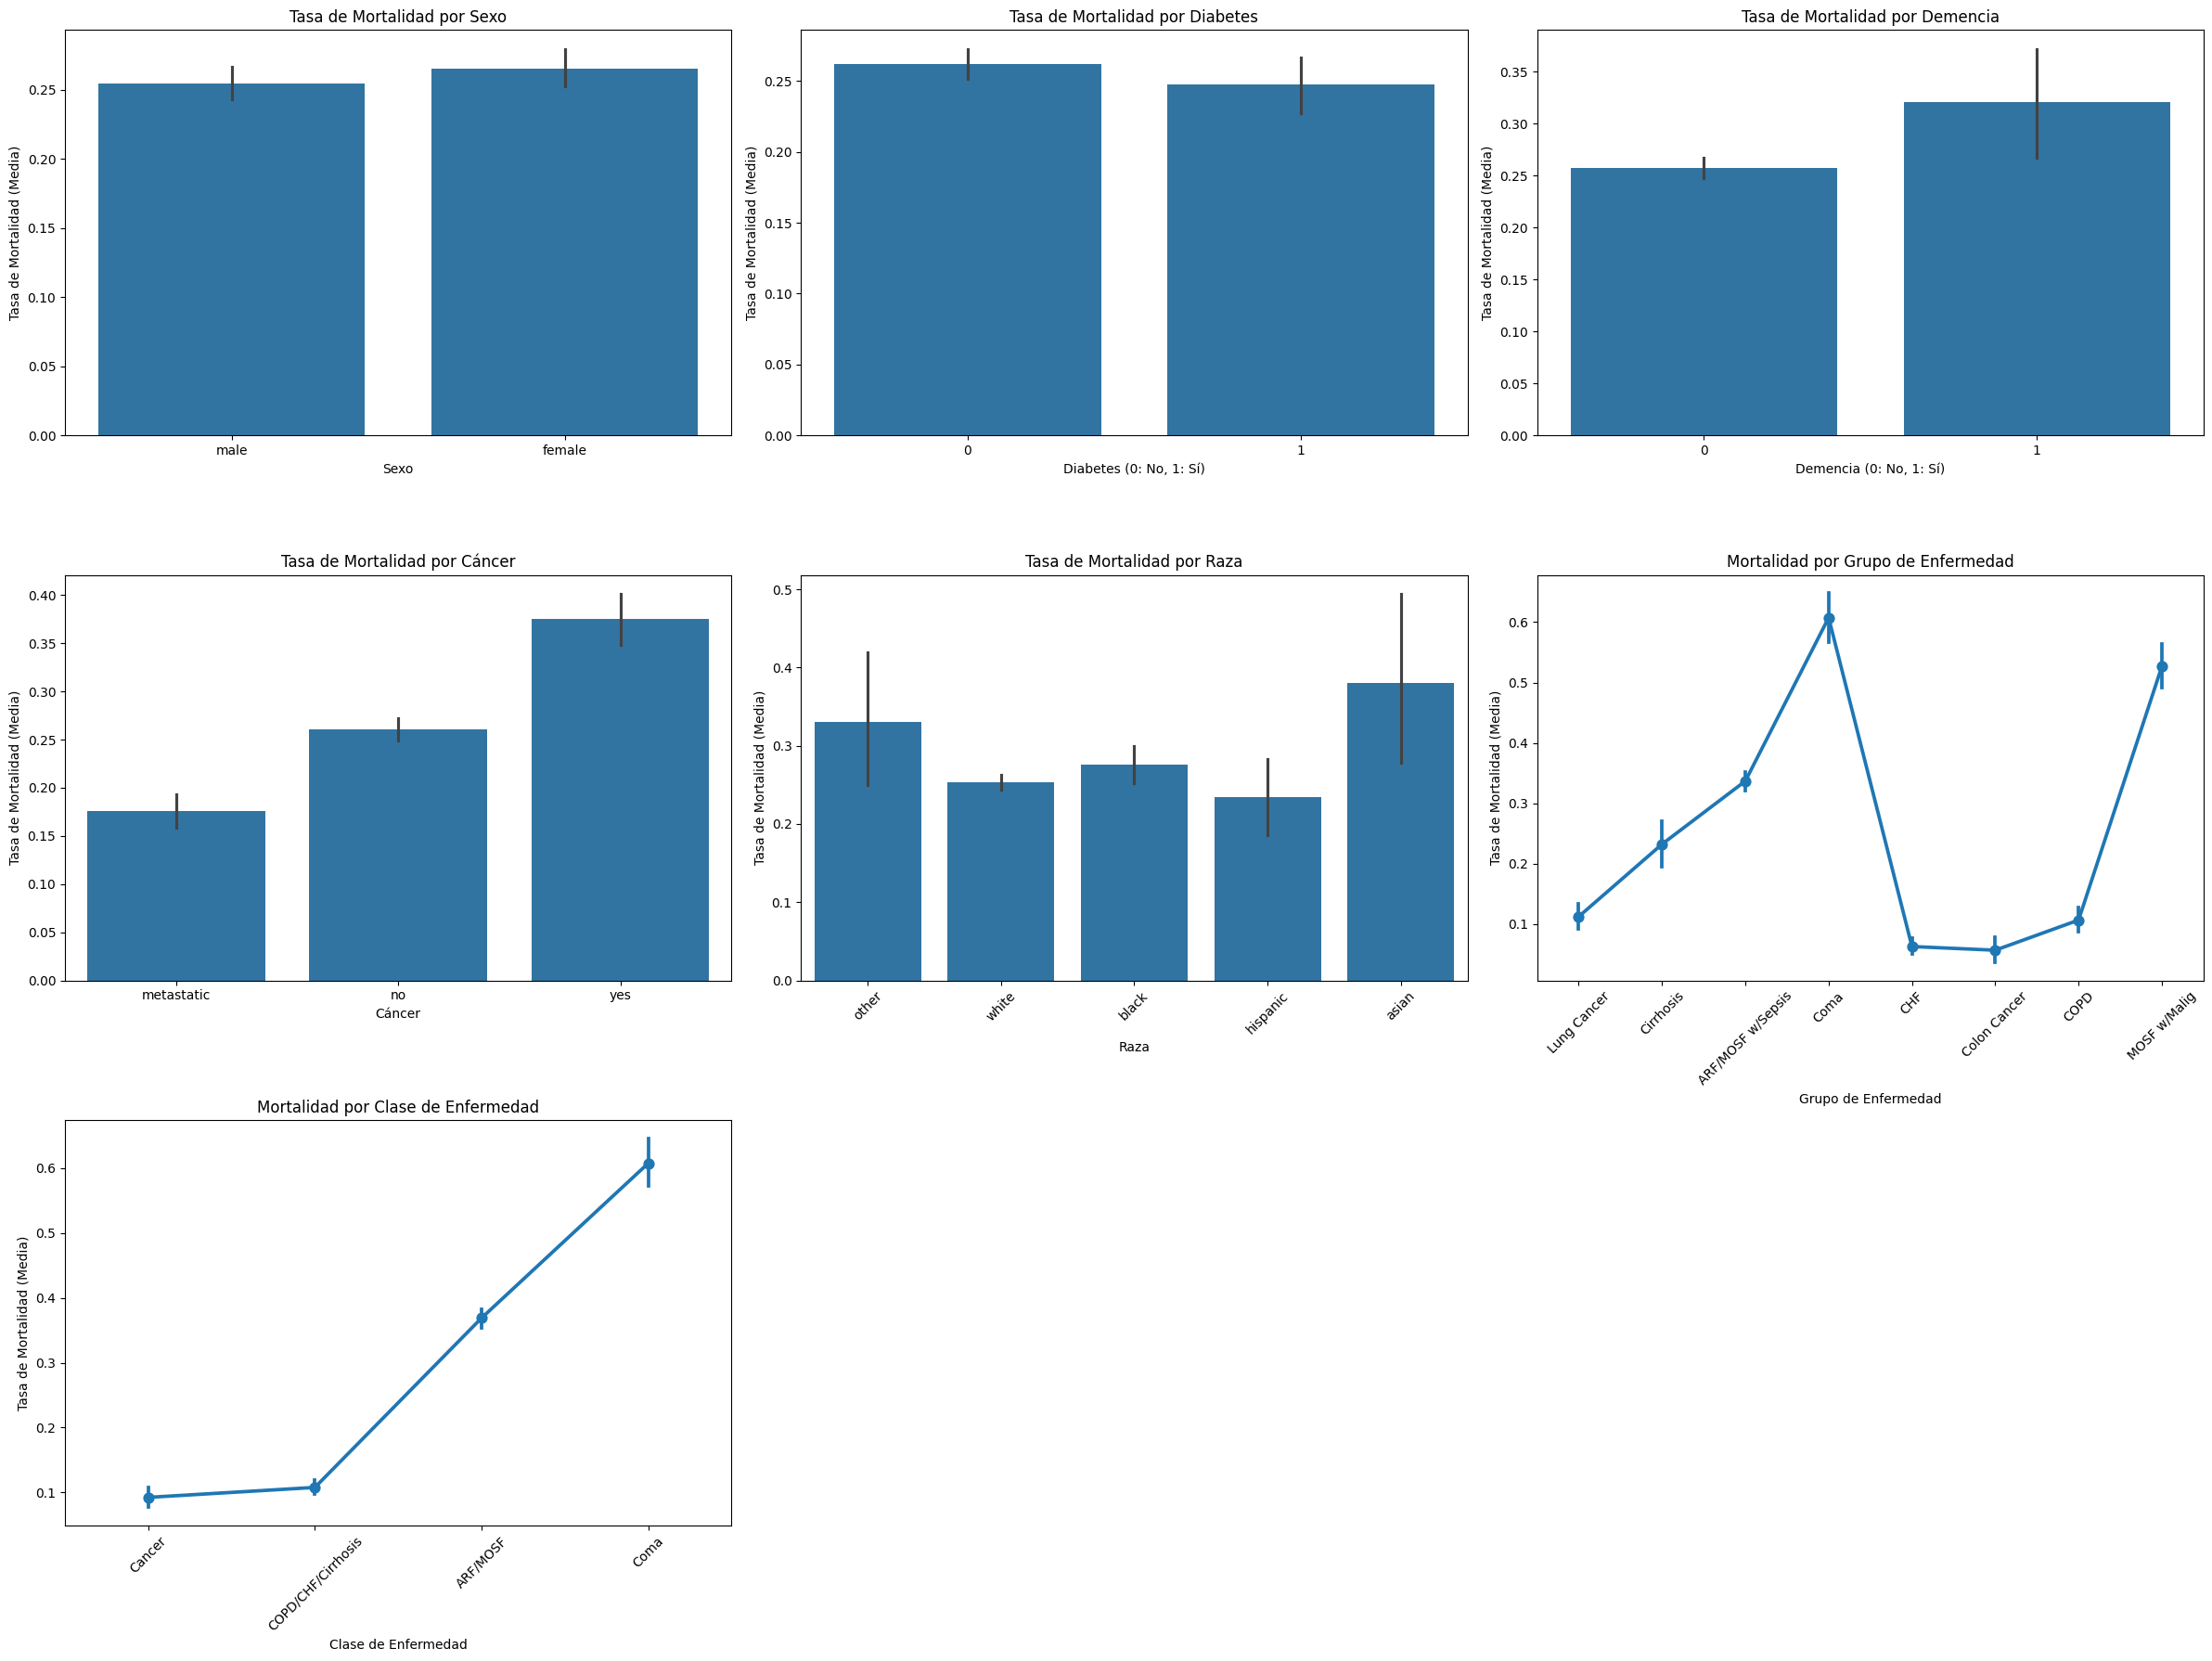

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(24, 18))

#Tasa de Mortalidad por Sexo ---
sns.barplot(x='sex', y='hospdead', data=data, ax=axes[0, 0])
axes[0, 0].set_title('Tasa de Mortalidad por Sexo')
axes[0, 0].set_xlabel('Sexo')
axes[0, 0].set_ylabel('Tasa de Mortalidad (Media)')

#Tasa de Mortalidad por Diabetes ---
sns.barplot(x='diabetes', y='hospdead', data=data, ax=axes[0, 1])
axes[0, 1].set_title('Tasa de Mortalidad por Diabetes')
axes[0, 1].set_xlabel('Diabetes (0: No, 1: Sí)')
axes[0, 1].set_ylabel('Tasa de Mortalidad (Media)')

#Tasa de Mortalidad por Demencia ---
sns.barplot(x='dementia', y='hospdead', data=data, ax=axes[0, 2])
axes[0, 2].set_title('Tasa de Mortalidad por Demencia')
axes[0, 2].set_xlabel('Demencia (0: No, 1: Sí)')
axes[0, 2].set_ylabel('Tasa de Mortalidad (Media)')

#Tasa de Mortalidad por Cáncer ---
sns.barplot(x='ca', y='hospdead', data=data, ax=axes[1, 0])
axes[1, 0].set_title('Tasa de Mortalidad por Cáncer')
axes[1, 0].set_xlabel('Cáncer')
axes[1, 0].set_ylabel('Tasa de Mortalidad (Media)')

#Tasa de Mortalidad por Raza ---
sns.barplot(x='race', y='hospdead', data=data, ax=axes[1, 1])
axes[1, 1].set_title('Tasa de Mortalidad por Raza')
axes[1, 1].set_xlabel('Raza')
axes[1, 1].set_ylabel('Tasa de Mortalidad (Media)')
axes[1, 1].tick_params(axis='x', rotation=45)

#Tasa de Mortalidad por Grupo de Enfermedad (dzgroup) ---
sns.pointplot(x='dzgroup', y='hospdead', data=data, ax=axes[1, 2])
axes[1, 2].set_title('Mortalidad por Grupo de Enfermedad')
axes[1, 2].set_xlabel('Grupo de Enfermedad')
axes[1, 2].set_ylabel('Tasa de Mortalidad (Media)')
axes[1, 2].tick_params(axis='x', rotation=45)

#Tasa de Mortalidad por Clase de Enfermedad (dzclass) ---
sns.pointplot(x='dzclass', y='hospdead', data=data, ax=axes[2, 0])
axes[2, 0].set_title('Mortalidad por Clase de Enfermedad')
axes[2, 0].set_xlabel('Clase de Enfermedad')
axes[2, 0].set_ylabel('Tasa de Mortalidad (Media)')
axes[2, 0].tick_params(axis='x', rotation=45)

# Eliminar los subgráficos no utilizados
fig.delaxes(axes[2, 1])
fig.delaxes(axes[2, 2])

plt.tight_layout()
plt.show()

De acuerdo con el análisis exploratorio realizado a partir de las gráficas, los hallazgos iniciales sobre la relación entre las variables categóricas y la mortalidad hospitalaria (hospdead) son los siguientes:

**Tasa de Mortalidad por Sexo**
Se observa que la tasa de mortalidad es prácticamente idéntica tanto para el género Masculino como para el Femenino. Esta paridad sugiere que la variable sex no es un factor determinante o diferenciador en la incidencia de la mortalidad dentro del contexto de este estudio.

**Tasa de Mortalidad por Diabetes**
Al igual que con la variable de sexo, la diferencia en la tasa de mortalidad entre pacientes con y sin diabetes no es lo suficientemente pronunciada como para considerarla un factor decisivo o de alta relevancia predictiva por sí sola.

**Tasa de Mortalidad por Demencia**
La demencia parece estar fuertemente asociada con una mayor mortalidad en pacientes. Por lo tanto, se concluye que la variable dementia es un factor importante y potencialmente clave para la predicción del evento de interés.

**Tasa de Mortalidad por Cáncer**
Se observa que el cáncer metastásico es un factor que incrementa significativamente la incidencia de mortalidad. En consecuencia, esta variable se establece como un predictor crucial en el modelo.

**Tasa de Mortalidad por Raza**
Aunque se presentan valores atípicos altos en la tasa de mortalidad para la raza asiática, la evidencia gráfica no es concluyente. Se requerirá un análisis estadístico más profundo para determinar si esta variable (race) tiene una incidencia fuerte y estadísticamente significativa como factor de mortalidad.

**Tasa de Mortalidad por Grupo de Enfermedad**
Esta variable (dzgroup) muestra picos de mortalidad importantes especialmente en los grupos relacionados con coma y cirrosis. Por esta razón, se determina que esta variable es un factor clave y de alto valor predictivo para la modelización.

Finalmente, se han identificado varias mediciones médicas de tipo numérico que también aportarán información esencial en la construcción de los modelos predictivos para alcanzar el objetivo planteado.

In [ ]:
data.shape

(9105, 27)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9105 entries, 0 to 9104
Data columns (total 27 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  9105 non-null   int64  
 1   age         9105 non-null   float64
 2   sex         9105 non-null   object 
 3   dzgroup     9105 non-null   object 
 4   dzclass     9105 non-null   object 
 5   num.co      9105 non-null   int64  
 6   scoma       9104 non-null   float64
 7   avtisst     9023 non-null   float64
 8   race        9063 non-null   object 
 9   sps         9104 non-null   float64
 10  aps         9104 non-null   float64
 11  surv2m      9104 non-null   float64
 12  surv6m      9104 non-null   float64
 13  hday        9105 non-null   int64  
 14  diabetes    9105 non-null   int64  
 15  dementia    9105 non-null   int64  
 16  ca          9105 non-null   object 
 17  dnr         9075 non-null   object 
 18  dnrday      9075 non-null   float64
 19  meanbp      9104 non-null  

Encontramos dentro de la estructura de datos del datset, un conjunto de variables de tipo interas, flotantes, y tambien tipo objeto, lo cual reforzando lo mencionado anteriormente hace necesario un preprocesamiento de datos previo a entrar a las fase de modelamiento.

In [ ]:
nulos_por_columna = data.isnull().sum()
nulos_existentes = nulos_por_columna[nulos_por_columna > 0]
nulos_ordenados = nulos_existentes.sort_values(ascending=False)
df_nulos = pd.DataFrame({
    'Total Nulos': nulos_ordenados,
    'Porcentaje Nulos': (nulos_ordenados / len(data_cruda)) * 100
})

print("Listado de Valores Nulos Ordenados (de Mayor a Menor):")
print(df_nulos)

Listado de Valores Nulos Ordenados (de Mayor a Menor):
         Total Nulos  Porcentaje Nulos
avtisst           82          0.900604
crea              67          0.735859
race              42          0.461285
dnr               30          0.329489
dnrday            30          0.329489
sps                1          0.010983
scoma              1          0.010983
surv6m             1          0.010983
surv2m             1          0.010983
aps                1          0.010983
meanbp             1          0.010983
hrt                1          0.010983
resp               1          0.010983
temp               1          0.010983
sod                1          0.010983


Como ya lo habiamos mencionado anteriormente, se han detectado datos faltante en el set de datos. Debido a la criticidad del contexto medico (mortalidad) para poder encontrar la mejor estrategia de generalización de los modelos, se define poder usar estrategias que maximen al maximo el uso de los datos, por lo menos en esta primera etapa de analisis de prepocesamiento.

In [ ]:
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
df_analisis_imputacio = pd.read_excel('analisis_imputacion.xlsx')
df_analisis_imputacio

,Nombre de la Variable(s),Naturaleza,Estrategia Recomendada,Técnica de Imputación,Justificación Clínica (Conocimiento Experto)
0,avtisst,Evaluación Funcional/Score,KNN Imputer (5 Vecinos),KNNImputer(n_neighbors=5),"Precisión Fisiológica: Como score complejo, su valor faltante se estima mejor con datos de pacientes que son fisiológicamente similares (sus ""vecinos""). Esto preserva las relaciones clínicas no lineales."
1,crea (Creatinina),Laboratorio,Imputación por Mediana,SimpleImputer(strategy='median'),Robustez a Fallo Renal: La creatinina es un biomarcador clave. Su distribución es a menudo sesgada por pacientes con fallo renal (valores muy altos). La mediana previene que estos outliers sesguen el valor imputado.
2,"sps, aps, scoma",Scores de Gravedad,Imputación por Mediana,SimpleImputer(strategy='median'),"Representación Central: Estos scores buscan medir el estado de gravedad. La mediana representa el valor más típico o central del grupo de pacientes, asumiendo un estado de gravedad promedio para el dato faltante."
3,"meanbp, hrt, resp, temp, sod",Signos Vitales / Lab.,Imputación por Mediana,SimpleImputer(strategy='median'),"Sensibilidad al Choque: Los valores extremos (muy altos o muy bajos, típicos de crisis como el shock o sepsis) sesgarían la media. La mediana evita sobreestimar o subestimar la gravedad del paciente faltante."
4,race (Raza/Etnia),Demográfica,Imputación por Moda,SimpleImputer(strategy='most_frequent'),"Mantenimiento de Proporciones: Al imputar con la moda (categoría más frecuente), se mantiene la proporción demográfica de la muestra. Es el enfoque más simple y menos sesgado para datos categóricos con pocos faltantes."
5,dnr,Orden DNR,Imputación por Valor Fijo: 0 (No DNR),"SimpleImputer(strategy='constant', fill_value=0)","Principio Ético: En medicina, la asunción por defecto (y principio ético) es realizar la reanimación a menos que exista una orden explícita de No Reanimar (DNR). Si el registro está vacío, se asume que la orden no existe (0)."
6,dnrday,Día de la Orden DNR,Imputación por Mediana,SimpleImputer(strategy='median'),"Neutralidad Temporal: Imputar con la mediana de los días registrados es una suposición neutral sobre cuándo se toma la decisión, evitando un sesgo artificial hacia el día de ingreso (Día 1)."
7,"surv2m, surv6m",Supervivencia,Imputación por Valor Fijo: 1 (Vivo),"SimpleImputer(strategy='constant', fill_value=1)","Censura de Datos: En análisis de supervivencia, si un paciente no tiene registro del evento de ""muerte"" en ese periodo específico, se le trata como censurado/vivo (1). Asumir la muerte introduciría un sesgo fatal."


Asi, debido a no contar con un diccionario de datos o acompañamiento de un experto en la materia, fue necesario realizar investigaciones sobre los tipo de los datos y su influencia directa en el desarrollo de la estrategia de generalziación de los modelos. Asi se presenta la tabla anterior que describe claramente la estrategia de imputación de datos. Con esta estrategia se plantea superar el desafio de datos faltantes bajo la premisa de maximizar el uso de estos en esta fase de preprocesamiento.

In [ ]:
data_cruda.duplicated().sum()

np.int64(0)

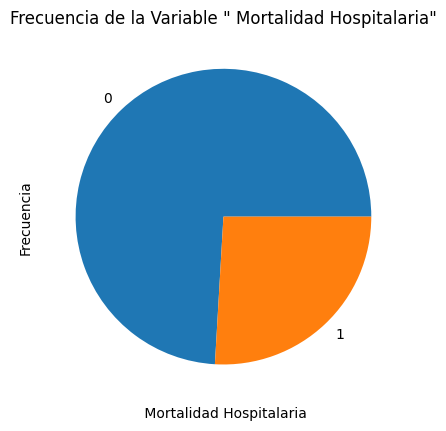

Resumen de Frecuencia de la Variable 'hospdead':
          Conteo Absoluto  Porcentaje
hospdead                             
Vivo                 6745       74.08
Muerto               2360       25.92


In [ ]:
data['hospdead'].value_counts().plot(kind='pie')
plt.title('Frecuencia de la Variable " Mortalidad Hospitalaria"')
plt.xlabel(' Mortalidad Hospitalaria')
plt.ylabel('Frecuencia')
plt.show()
print("Resumen de Frecuencia de la Variable 'hospdead':")
conteo_absoluto = data['hospdead'].value_counts()
conteo_porcentual = (conteo_absoluto / len(data)) * 100
resumen_mortalidad = pd.DataFrame({
    'Conteo Absoluto': conteo_absoluto,
    'Porcentaje': conteo_porcentual.round(2)
})
resumen_mortalidad.rename(index={0: 'Vivo', 1: 'Muerto'}, inplace=True)
print(resumen_mortalidad)


Otro desafio importante es el desabalance de los datos encontrados en la clase dependiente. Por lo anterior y basado en la criticidad de los datos, se evaluará la mejor técnica para su respectivo procesamiento, usando técnicas de sobre muestro o bajo muestreo. Asi como tambien evaluar posibles modelos que permiten manejar este tipo de desafios para lograr la mayor genalización de los modelos.

In [ ]:
X = data.drop('hospdead', axis=1)
y = data['hospdead']

A partir de aqui se propone implementar un pipeline que permita:
- Imputación de datos basado en la estrategia anteriormente mencionada donde planteamos estrategias a nivel de KNN, Media, OHC entre otras.
- Aseguramos que todos los datos esten en la misma escala usando StandarSCaler.
- Elimina la variable Unamed ya que no tiene ningun aporte en la conformación de los datos del dataset.

In [ ]:
# Variables que ya están limpias (sin nulos) y solo necesitan escalar
passthrough_scale_features_ajustado = ['age', 'num.co', 'hday', 'diabetes', 'dementia', 'adlsc']

# Variable a ser procesadas bajo proceso de imputación

knn_features = ['avtisst']
median_features = ['crea', 'sps', 'aps', 'scoma', 'meanbp', 'hrt', 'resp', 'temp', 'sod', 'dnrday']
constante_cero_features = [] # La dejamos vacía si movimos 'dnr' a OHE
constante_uno_features = ['surv2m', 'surv6m']
categorical_ohe_features_ajustado = ['race', 'sex', 'dzgroup', 'dzclass', 'ca', 'dnr']


#Defición de los subpipelines para preprocesmiento de los datos

knn_scaler_transformer = Pipeline(steps=[
    ('knn_imputer', KNNImputer(n_neighbors=5)),
    ('scaler', StandardScaler())
])

median_scaler_transformer = Pipeline(steps=[
    ('median_imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('mode_imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

constant_zero_transformer = Pipeline(steps=[
    ('const', SimpleImputer(strategy='constant', fill_value=0))
])

constant_one_transformer = Pipeline(steps=[
    ('const', SimpleImputer(strategy='constant', fill_value=1))
])

pre_procesamiento = ColumnTransformer(
    transformers=[
        # 1. Imputación por KNN + Escalado
        ('knn_scale', knn_scaler_transformer, knn_features),
        # 2. Imputación por Mediana + Escalado
        ('median_scale', median_scaler_transformer, median_features),
        # 3. Moda + OHE
        ('cat', categorical_transformer, categorical_ohe_features_ajustado),
        # 4. Constante UNO
        ('const_one', constant_one_transformer, constante_uno_features),
        # 5. Escalar variables limpias (USA LA LISTA AJUSTADA)
        ('passthrough_scale', StandardScaler(), passthrough_scale_features_ajustado)
    ],
    remainder='drop'
)
X_transformado_array = pre_procesamiento.fit_transform(X)
X_transformado_df = pd.DataFrame(X_transformado_array, columns=pre_procesamiento.get_feature_names_out(), index=X.index)


ASi pasamos de una dimensionalidad de 27 variable a 44, lo cual considero que no representa mayor complejidad

In [ ]:
X_transformado_df.shape

(9105, 44)

Dado que nos interesa mantener la interpretabilidad de las variables dentro del dataset para un mejor entendimiento del contexto clínico, se propone realizar una selección de características. Esta estrategia nos permitirá identificar las variables más relevantes y eliminar aquellas que aporten ruido al modelo, sin transformarlas. Aunque se podría usar la matriz de covarianza para la extracción de características (a través de técnicas como PCA), esta opción no se considera ya que las nuevas variables o componentes no tendrían una interpretación clínica clara. En su lugar, se sugiere usar la matriz de covarianza para identificar la colinealidad entre variables y así poder seleccionar aquellas que sean más independientes y menos redundantes

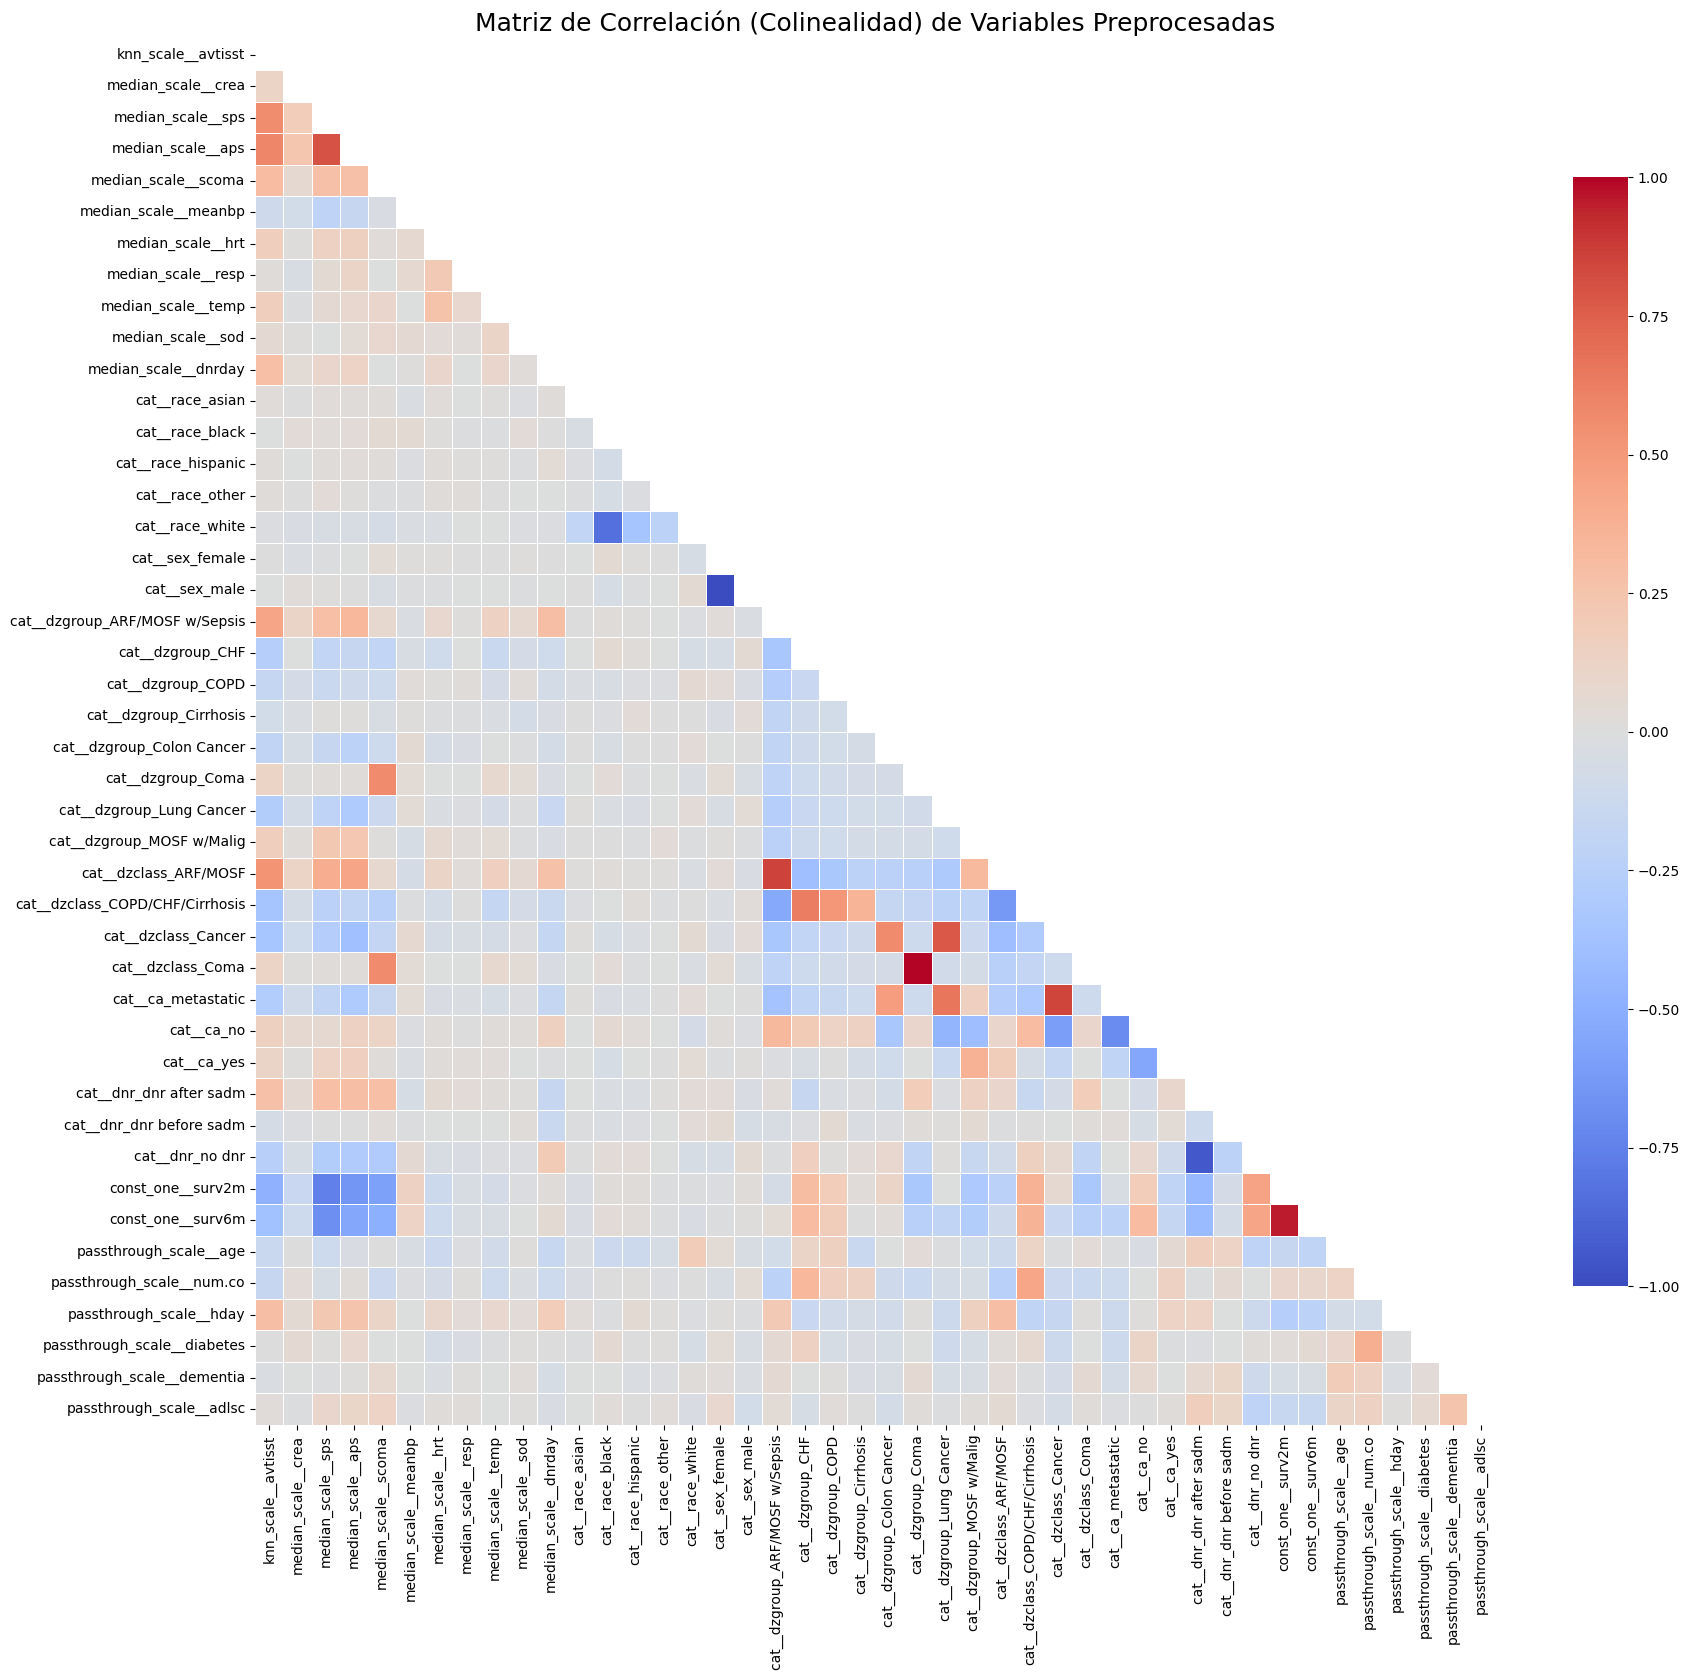


--- Pares de Variables con Correlación Absoluta > 0.8 ---
cat__dzclass_Coma      cat__dzgroup_Coma                 1.000000
const_one__surv6m      const_one__surv2m                 0.960408
cat__dzclass_ARF/MOSF  cat__dzgroup_ARF/MOSF w/Sepsis    0.851847
cat__ca_metastatic     cat__dzclass_Cancer               0.848943
cat__race_white        cat__race_black                  -0.834699
cat__dnr_no dnr        cat__dnr_dnr after sadm          -0.942993
cat__sex_male          cat__sex_female                  -1.000000
dtype: float64


In [ ]:
# Calculamos la matriz de correlacion para todas las caracterticias
correlation_matrix = X_transformado_df.corr()
correlation_matrix = X_transformado_df.corr()
plt.figure(figsize=(20, 18))
mask = np.triu(correlation_matrix)
sns.heatmap(
    correlation_matrix,
    mask=mask,
    annot=False,
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)

plt.title('Matriz de Correlación (Colinealidad) de Variables Preprocesadas', fontsize=18)
plt.show()
upper_triangle = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
high_corr_pairs = upper_triangle.unstack().sort_values(ascending=False).drop_duplicates()
high_corr_pairs = high_corr_pairs[(high_corr_pairs > 0.8) | (high_corr_pairs < -0.8)]
print("\n--- Pares de Variables con Correlación Absoluta > 0.8 ---")
print(high_corr_pairs)

In [ ]:
X_transformado_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9105 entries, 0 to 9104
Data columns (total 44 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   knn_scale__avtisst               9105 non-null   float64
 1   median_scale__crea               9105 non-null   float64
 2   median_scale__sps                9105 non-null   float64
 3   median_scale__aps                9105 non-null   float64
 4   median_scale__scoma              9105 non-null   float64
 5   median_scale__meanbp             9105 non-null   float64
 6   median_scale__hrt                9105 non-null   float64
 7   median_scale__resp               9105 non-null   float64
 8   median_scale__temp               9105 non-null   float64
 9   median_scale__sod                9105 non-null   float64
 10  median_scale__dnrday             9105 non-null   float64
 11  cat__race_asian                  9105 non-null   float64
 12  cat__race_black     

Dado la estrategia de reduccion dimensionalidad planteada, se plantea la siguiente eliminación de variable con el siguiente sustento:
- cat__sex_female: Esto basado en el principio de redundancia en la codificación one-hot.
- median_scale__sps: Esta variable presenta una alta colinealidad con la variable aps.
- cat__dnr_no dnr: Ya se tiene una varaible ndr.
- cat__dzgroup_MOSF w/Malig y cat__dzclass_Cancer: Alta colinealidad con dzgroup y la categoria de Cancer en dzclass
- const_one__surv6m: Esta variable tiene datos que ya pueden ser capturados por la varaible surv2m, ademas de presentarse como una constante.
Con esto se espera ayudar en la eliminación de duplicidad en los datosy eliminación de ruido que pueda llegar los modelos.

In [ ]:
#Reduccion de dimensionalidad manual
X_transformado_df_limpio = X_transformado_df.copy()
columnas_a_eliminar_solo_sex = [
    # Redundancia de Codificación Categórica (N-1)
    'cat__sex_female',

    # Otras variables redundantes (si aún existen)
    'median_scale__sps',
    'cat__dnr_no dnr',
    'cat__dzgroup_MOSF w/Malig',
    'cat__dzclass_Cancer',
    'const_one__surv6m',
]
columnas_existentes = X_transformado_df_limpio.columns.tolist()
columnas_a_eliminar_existentes = [
    col for col in columnas_a_eliminar_solo_sex if col in columnas_existentes
]

if columnas_a_eliminar_existentes:
    data_limpia = X_transformado_df_limpio.drop(
        columns=columnas_a_eliminar_existentes,
        axis=1
    )

    print("Eliminación exitosa de las columnas redundantes existentes.")
    print(f"Columna 'cat__sex_female' fue eliminada: {'cat__sex_female' in columnas_a_eliminar_existentes}")
    print(f"Número de columnas después de la limpieza: {data_limpia.shape[1]}")
    print("\nPrimeras columnas del DataFrame limpio:")
    print(data_limpia.columns.tolist()[:5])

Eliminación exitosa de las columnas redundantes existentes.
Columna 'cat__sex_female' fue eliminada: True
Número de columnas después de la limpieza: 38

Primeras columnas del DataFrame limpio:
['knn_scale__avtisst', 'median_scale__crea', 'median_scale__aps', 'median_scale__scoma', 'median_scale__meanbp']


# ***Evidencia del entrenamiento apropiado de los modelos.***

Como estrategia de entrenamiento, planteamos un slpit de entrenamiento 80% y pruebas 20%

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(data_limpia, y, test_size=0.2, random_state=42, stratify=y)
rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)

Se plantea entrenar los siguinete modelos:

**Regresión Logística y SVC (Lineal y No Lineal):** Por su interpretabilidad en el contexto clinico será importante tenerlo encuentra. Como parte de sus caracteristicas lso cuales son rapidos en su entrenamiento y generalización con L1 y L2. Como parte sus desafios se requieren la normalización de los datos los cuales ya fueron considerados. Son sensibles a desbalanceo, el cual se intenta mitigar con el submuestro realizado. **Como parte del entrenamiento se plantea el uso de un GRdiSearch para Regresión Logistica encontrar los mejores parámetros (C, penalty) y validar que el modelo está bien ajustado, lo mismo para SVM lineal usando RadomSearch.**

**SVC con Kernel RBF:** Como parte del analisis se buscaba limites no lineales, para datos con clase no lineales. Demanda una alto nivel de capacidad de computo y es muy poco interpretable. Lo anterior no es muy bueno en elescenario medico actual. Cuenta con capacidad para modelar relaciones complejas lo hace propenso a un sobreajuste si no se ajusta correctamente el parámetro C. Un valor alto de C puede llevar a un sobreajuste, mientras que un valor bajo puede resultar en un modelo demasiado simple. **Como parte del entrenamiento se plantea la optimización con RandomizedSearchCV es crucial. La exploración  del hiperparámetro C en una escala logarítmica (loguniform) es una estrategia adecuada para encontrar el valor óptimo que equilibre el bias y la varianza, y valide que el modelo no está sobreajustado.**

**Modelos Basados en Árboles (RandomForest, BalancedRandomForest, XGBoost)**: Son ideales para datos con relaciones complejas. Un punto a considerar es que son menos interpretables. Especialmente el XGBoost es propenso al sobreajuste.  El ajuste de hiperparámetros (max_depth, n_estimators, learning_rate) es crucial para controlar la complejidad del modelo y evitar que se sobreajuste a los datos de entrenamiento.BalancedRandomForest y XGBoost con el parámetro scale_pos_weight están diseñados para manejar el desbalance de clases de forma nativa, lo que es una gran ventaja para tu problema. **Como parte del entrenamiento se plantea una validación cruzada con StratifiedKFold es fundamental para confirmar que el modelo generaliza bien a nuevos datos. La optimización de hiperparámetros con RandomizedSearchCV es un paso correcto para encontrar el mejor modelo**

**RUSBoost (Random Under-Sampling Boost):** Modelo que permite manejar el desbalance de clases reduciendo el numero de muestras de la clase mayoritaria. Existe un riesgo de perder información importante de la clase mayoritaria. Como parte de la estrategia para evaluar el impacto de perdidas de datos es compararlo con otros modelos. **Como parte del entrenamiento se plantea el uso de RandomizedSearchCV que ayudará a encontrar el mejor balance entre el número de estimadores y la tasa de aprendizaje para evitar el overfitting y la pérdida de información.**

In [ ]:
# A. REGRESIÓN LOGÍSTICA (GridSearch)
param_grid_logreg = {
    'classifier': [LogisticRegression(max_iter=500, random_state=42, solver='saga')],
    'classifier__C': [0.1, 1.0, 10.0],
    'classifier__penalty': ['l1', 'l2']
}

# B1. Lineal (Más rápido con LinearSVC)
param_dist_linear_svc = {
    'classifier': [LinearSVC(random_state=42, dual=False, max_iter=2000)],
    'classifier__C': loguniform(1e-1, 1e2),
}

# B2. No Lineal (Usamos SVC solo para el kernel RBF)
param_dist_rbf_svc = {
    'classifier': [SVC(probability=True, random_state=42)],
    'classifier__C': loguniform(1e-1, 1e2),
    'classifier__kernel': ['rbf']
}

param_dist_xgb = {
    'classifier': [XGBClassifier(eval_metric='logloss', scale_pos_weight=2.86, random_state=42, n_jobs=-1)],
    'classifier__n_estimators': randint(500, 1000),
    'classifier__max_depth': randint(2, 4),
    'classifier__learning_rate': loguniform(1e-4, 0.05),
    'classifier__subsample': [0.6, 0.7, 0.8],
    'classifier__colsample_bytree': [0.6, 0.7, 0.8],
    'classifier__gamma': loguniform(1e-3, 1),
    'classifier__reg_alpha': loguniform(1, 10),
    'classifier__reg_lambda': loguniform(1, 10),
    'classifier__min_child_weight': randint(1, 10)
}

param_dist_rusboost = {
    'classifier': [RUSBoostClassifier(random_state=42)],
    'classifier__n_estimators': randint(50, 200),
    'classifier__learning_rate': loguniform(1e-3, 0.1),
}

scoring_metrics = {
    'Accuracy': make_scorer(accuracy_score),
    'Precision_Weighted': make_scorer(precision_score, average='weighted'),
    'Recall_Weighted': make_scorer(recall_score, average='weighted'),
    'F1_Weighted': make_scorer(f1_score, average='weighted')
}

param_dist_rf = {
    'classifier': [RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)],
    'classifier__n_estimators': randint(100, 500),
    'classifier__max_depth': [5, 7, 10],
    'classifier__min_samples_split': randint(10, 50),
    'classifier__min_samples_leaf': randint(5, 20),
    'classifier__criterion': ['gini', 'entropy'],
    'classifier__max_features': ['sqrt', 0.8],
}

param_dist_brf = {
    'classifier': [BalancedRandomForestClassifier(random_state=42, n_jobs=-1)],
    'classifier__n_estimators': randint(100, 500),
    'classifier__max_depth': [5, 7, 10],
    'classifier__min_samples_split': randint(10, 50),
    'classifier__min_samples_leaf': randint(5, 20),
}


# --- CONSOLIDACIÓN DE BUSQUEDAS) ---
search_configs = [
    # GridSearch (Logistic Regression)
    {'model_name': 'LogisticRegression', 'search_type': 'GridSearch', 'params': param_grid_logreg},

    # Randomized Search (SVMs)
    {'model_name': 'SVCRBF', 'search_type': 'RandomSearch', 'params': param_dist_rbf_svc},
    {'model_name': 'SVCLinear', 'search_type': 'RandomSearch', 'params': param_dist_linear_svc},

    # Randomized Search (Modelos de Árboles)
    {'model_name': 'RandomForest', 'search_type': 'RandomSearch', 'params': param_dist_rf},
    {'model_name': 'BalancedRandomForest', 'search_type': 'RandomSearch', 'params': param_dist_brf},
    {'model_name': 'XGBoost', 'search_type': 'RandomSearch', 'params': param_dist_xgb},
    {'model_name': 'RUSBoost', 'search_type': 'RandomSearch', 'params': param_dist_rusboost}
]
cv_strategy_grid = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_strategy_rand = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)

In [ ]:
# --- BUCLE PRINCIPAL DE EVALUACIÓN ---
best_models = {}
metricas_finales = []
n_iter_rand = 12

print("--- INICIO DE BÚSQUEDA HÍBRIDA (GridSearch y RandomSearch) ---")

scoring_metrics = {
    'Accuracy': make_scorer(accuracy_score),
    'Precision_Weighted': make_scorer(precision_score, average='weighted'),
    'Recall_Weighted': make_scorer(recall_score, average='weighted'),
    'F1_Weighted': make_scorer(f1_score, average='weighted')
}


for config in tqdm(search_configs, desc="Búsqueda Híbrida de Modelos"):

    # Obtenemos configuración
    model_name = config['model_name']
    search_type = config['search_type']
    param_config = config['params']

    # Inicialización del Pipeline (El escalador debe ir aquí si lo necesita)
    classifier_instance = param_config['classifier'][0]
    pipeline_base = ImbPipeline([
        ('classifier', classifier_instance)
    ])

    # Preparación de Parámetros de Búsqueda
    param_config_search = {k: v for k, v in param_config.items() if k != 'classifier'}

    # Logica condicional de Busqueda
    if search_type == 'GridSearch':
        cv_strategy = cv_strategy_grid
        search_class = GridSearchCV
        search_kwargs = {}
        print(f"\n[GRID] Buscando: {model_name}...")

    elif search_type == 'RandomSearch':
        cv_strategy = cv_strategy_rand
        search_class = RandomizedSearchCV
        search_kwargs = {'n_iter': n_iter_rand, 'random_state': 42}
        print(f"\n[RANDOM] Buscando: {model_name} (Iteraciones: {n_iter_rand})")

    else:
        raise ValueError(f"Tipo de búsqueda no válido: {search_type}")

    # Ejecución del Search (Grid o Ramdom)
    search = search_class(
        pipeline_base,
        param_config_search,
        cv=cv_strategy,
        scoring='f1',
        n_jobs=-1,
        verbose=3,
        **search_kwargs
    )

    # Entrenar el modelo
    search.fit(X_train_rus, y_train_rus)
    y_pred_rus = search.best_estimator_.predict(X_train_rus)
    accuracy = accuracy_score(y_train_rus, y_pred_rus)
    print(f"Predicciones del modelo: {Counter(y_pred_rus)}")
    # Almacenar el mejor estimador y métricas
    key = f'{model_name}_{param_config}'
    best_estimator = search.best_estimator_
    best_models[key] = best_estimator

    print(f" -> Score F1 (Optimización CV): {search.best_score_:.4f}")
    print(f" -> Mejores Params: {search.best_params_}")

    # CÁLCULO DE MÚLTIPLES MÉTRICAS CON VALIDACIÓN CRUZADA
    cv_results = cross_validate(
    best_estimator,
    X_train_rus,
    y_train_rus,
    scoring=scoring_metrics,
    cv=cv_strategy,
    n_jobs=-1,
    )
    df_cv_results = pd.DataFrame(cv_results)
    df_sorted_by_f1 = df_cv_results.sort_values(by='test_F1_Weighted', ascending=False)
    print(df_sorted_by_f1)
    # CALCULAR PROMEDIOS FINALES DEL K-FOLD PARA EL REPORTE
    accuracy_cv = np.mean(cv_results['test_Accuracy'])
    precision_cv = np.mean(cv_results['test_Precision_Weighted'])
    recall_cv = np.mean(cv_results['test_Recall_Weighted'])
    f1_cv = np.mean(cv_results['test_F1_Weighted'])

    # Reporte Final
    metricas_finales.append({
       'Conjunto': 'Entrenamiento',
       'Modelo': model_name,
       'Accuracy': accuracy_cv,
       'Precision': precision_cv,
       'Recall': recall_cv,
       'F1_Score': f1_cv
        })

print("\n------------------------------------\n")
print("Proceso de Búsqueda Híbrida completado. Resultados:")


--- INICIO DE BÚSQUEDA HÍBRIDA (GridSearch y RandomSearch) ---


Búsqueda Híbrida de Modelos:   0%|          | 0/7 [00:00<?, ?it/s]


[GRID] Buscando: LogisticRegression...
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Predicciones del modelo: Counter({np.int64(1): 1902, np.int64(0): 1874})
 -> Score F1 (Optimización CV): 0.8725
 -> Mejores Params: {'classifier__C': 10.0, 'classifier__penalty': 'l1'}
   fit_time  score_time  test_Accuracy  test_Precision_Weighted  test_Recall_Weighted  test_F1_Weighted
1  0.960539    0.028944       0.882119                 0.883082              0.882119          0.882041
3  1.814184    0.036369       0.874172                 0.874940              0.874172          0.874112
0  1.688654    0.039574       0.873016                 0.873058              0.873016          0.873012
4  1.192647    0.016331       0.867550                 0.868049              0.867550          0.867501
2  1.909179    0.032657       0.864901                 0.865937              0.864901          0.864811

[RANDOM] Buscando: SVCRBF (Iteraciones: 12)
Fitting 2 folds for each of 12 candidates, tot

Como parte de la seleccion del tipo de modelo, y metodo de selección de modelo y/o regularización utilizados he planteado una combinación de modelos lineales (LogisticRegression, SVC) y modelos basados en árboles (RandomForest, BalancedRandomForest, XGBoost, RUSBoost) para la selección del modelo. Esta estrategia es robusta porque permite comparar diferentes enfoques.
**Regresión Logística y SVC:** Con el uso de la regulización L1, L2 y C para controlar el sobre ajuste. Para Logsitic Regretion el parametro optimo C fue 10  con penalty=L1, lo que nos lleva a decir que el modelo llego a un buen balance al penalizar los coeficientes para evitar el sobreajute. Al igual lo mdoelos SVC con el paremtreo C que lograron controlar el margen de error.
**Modelos basao en Arboles:** Aunque utilizan un metodo de regualziación diferente, con el uso de max_depth, min_samples_leaf y n_estimators acutan como regualizadores.Por ejemplo, RandomForest y BalancedRandomForest tienen un max_depth de 5 y 10, respectivamente, lo que limita la complejidad de los árboles y evita el sobreajuste.

## Evidencia Nuemrica: Los resultados permiten demostrar a traves de la validación cruzada que los modelos fueron bien entrenados y la estrategia de seleccion funsiona.

Rendimiento General: Todos los modelos obuvieron un F1-score de validación cruzada mayor a 0,84. lo que indica una predicción solidad en la prediccion de mortalidad.

**Comparación de modelos: **Ramdomforest alcanzo un f1-score mas alto, lo que lo posiciona como el mejor modelo a nivel de desempeño general. Lo cual nos lleva a plantear que la realciones no lienales son importantes.

**Balanceo de Clase:** Se planeto un estrategia del manejo del desbalanceo con XGBoost y BalancedRamdomForest con buen desempeño. El modelo de BalancedRadomForest obtuvo un f1-score de 0,8729 muy cercano de la metrica de RadomForest standar, demostando que su manejo del balanceo fue efectivo sin sacrificar datos. Ruboost aunque fue usado para que manejara el submuestro obtuvo un metrica de 0,8466 mas baja, lo que podria indicar que la estrategia de sumuestreo no fue tan efectiva.

**Ajuste y Generalización:** Los tiempos de entrenamiento y las métricas de prueba (test_Accuracy, test_F1_Weighted) en cada split de la validación cruzada son consistentes, lo que indica que los modelos se están generalizando bien y no están sobreajustándose a un conjunto de datos específico. Por ejemplo, en el RandomForest, el F1-score es consistentemente alto en ambos pliegues (0.883466 y 0.868643), lo que demuestra un rendimiento estable y una buena capacidad de generalización.

In [ ]:
metricas_finales_pd = pd.DataFrame(metricas_finales)
metricas_finales_pd

,Conjunto,Modelo,Accuracy,Precision,Recall,F1_Score
0,Entrenamiento,LogisticRegression,0.872352,0.873013,0.872352,0.872295
1,Entrenamiento,SVCRBF,0.868114,0.868199,0.868114,0.868108
2,Entrenamiento,SVCLinear,0.869968,0.870003,0.869968,0.869965
3,Entrenamiento,RandomForest,0.876059,0.876122,0.876059,0.876054
4,Entrenamiento,BalancedRandomForest,0.872087,0.872379,0.872087,0.872060
5,Entrenamiento,XGBoost,0.859905,0.865381,0.859905,0.859374
6,Entrenamiento,RUSBoost,0.848782,0.849107,0.848782,0.848746


In [ ]:
print("--- INICIANDO CÁLCULO DE MÉTRICAS EN CONJUNTO DE PRUEBA (TEST) ---")
metricas_finales_test = []
for key, best_estimator in best_models.items():

    # Extracción de los nombres (Para limpiar la clave y asegurar que son strings)
    model_name, param_config_str = key.split('_', 1)

    #Limpiamos la cadena de parámetros para mejor visualización
    try:
        param_dict = eval(param_config_str)
        clean_params = ", ".join(f"{k.split('__')[-1]}:{v:.3g}" for k, v in param_dict.items())
    except Exception:
        clean_params = param_config_str # Si falla, usa la cadena original

    # Realizar predicciones y calcular métricas explícitamente
    y_pred = best_estimator.predict(X_test)

    # CÁLCULO DE LAS MÉTRICAS PONDERADAS DE PRUEBA
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    #Almacenar métricas de Prueba
    metricas_finales_test.append({
        'Conjunto': 'Prueba (Test)',
        'Modelo': model_name,
        #'Parametros': clean_params, # Usamos la versión limpia y segura (string)
       'Accuracy': accuracy,
       'Precision': precision,
       'Recall': recall,
       'F1_Score': f1
    })
    print(f" -> Evaluado: {model_name} con {clean_params} en PRUEBA")

print("\n------------------------------------\n")

df_metricas_cv = pd.DataFrame(metricas_finales_pd)
df_metricas_test = pd.DataFrame(metricas_finales_test)
df_final = pd.concat(
    [df_metricas_cv, df_metricas_test],
    ignore_index=True
).round(4)

# Ordenar por Modelo y Conjunto (Prueba y Entrenamiento)
df_final = df_final.sort_values(
    by=['Modelo', 'Conjunto'],
    ascending=[True, False]
)

print("=============== RESUMEN FINAL DE MÉTRICAS (CV vs. Prueba) ===============")
df_final

--- INICIANDO CÁLCULO DE MÉTRICAS EN CONJUNTO DE PRUEBA (TEST) ---
 -> Evaluado: LogisticRegression con {'classifier': [LogisticRegression(max_iter=500, random_state=42, solver='saga')], 'classifier__C': [0.1, 1.0, 10.0], 'classifier__penalty': ['l1', 'l2']} en PRUEBA
 -> Evaluado: SVCRBF con {'classifier': [SVC(probability=True, random_state=42)], 'classifier__C': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x792c5cdc0aa0>, 'classifier__kernel': ['rbf']} en PRUEBA
 -> Evaluado: SVCLinear con {'classifier': [LinearSVC(dual=False, max_iter=2000, random_state=42)], 'classifier__C': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x792c5cb3da00>} en PRUEBA
 -> Evaluado: RandomForest con {'classifier': [RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)], 'classifier__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x792c5cb3edb0>, 'classifier__max_depth': [5, 7, 10], 'classifier__min_samples_sp

,Conjunto,Modelo,Accuracy,Precision,Recall,F1_Score
11,Prueba (Test),BalancedRandomForest,0.8863,0.9002,0.8863,0.8898
4,Entrenamiento,BalancedRandomForest,0.8721,0.8724,0.8721,0.8721
7,Prueba (Test),LogisticRegression,0.8863,0.8985,0.8863,0.8896
0,Entrenamiento,LogisticRegression,0.8724,0.8730,0.8724,0.8723
13,Prueba (Test),RUSBoost,0.8693,0.8789,0.8693,0.8723
6,Entrenamiento,RUSBoost,0.8488,0.8491,0.8488,0.8487
10,Prueba (Test),RandomForest,0.8940,0.9011,0.8940,0.8962
3,Entrenamiento,RandomForest,0.8761,0.8761,0.8761,0.8761
9,Prueba (Test),SVCLinear,0.8885,0.9013,0.8885,0.8918
2,Entrenamiento,SVCLinear,0.8700,0.8700,0.8700,0.8700


========== ANÁLISIS DE RENDIMIENTO FINAL EN TEST ==========

--- LOGISTICREGRESSION ---
Matriz de Confusión:
Real Negativo | 1196 (VN) | 153 (FP) |
Real Positivo | 54 (FN) | 418 (VP) |
[[1196  153]
 [  54  418]]
   Sensibilidad (Recall): 0.8856
   Precisión Positiva: 0.7320
**AUC-ROC: 0.9468**

--- RANDOMFOREST ---
Matriz de Confusión:
Real Negativo | 1219 (VN) | 130 (FP) |
Real Positivo | 63 (FN) | 409 (VP) |
[[1219  130]
 [  63  409]]
   Sensibilidad (Recall): 0.8665
   Precisión Positiva: 0.7588
**AUC-ROC: 0.9516**

--- BALANCEDRANDOMFOREST ---
Matriz de Confusión:
Real Negativo | 1191 (VN) | 158 (FP) |
Real Positivo | 49 (FN) | 423 (VP) |
[[1191  158]
 [  49  423]]
   Sensibilidad (Recall): 0.8962
   Precisión Positiva: 0.7281
**AUC-ROC: 0.9535**


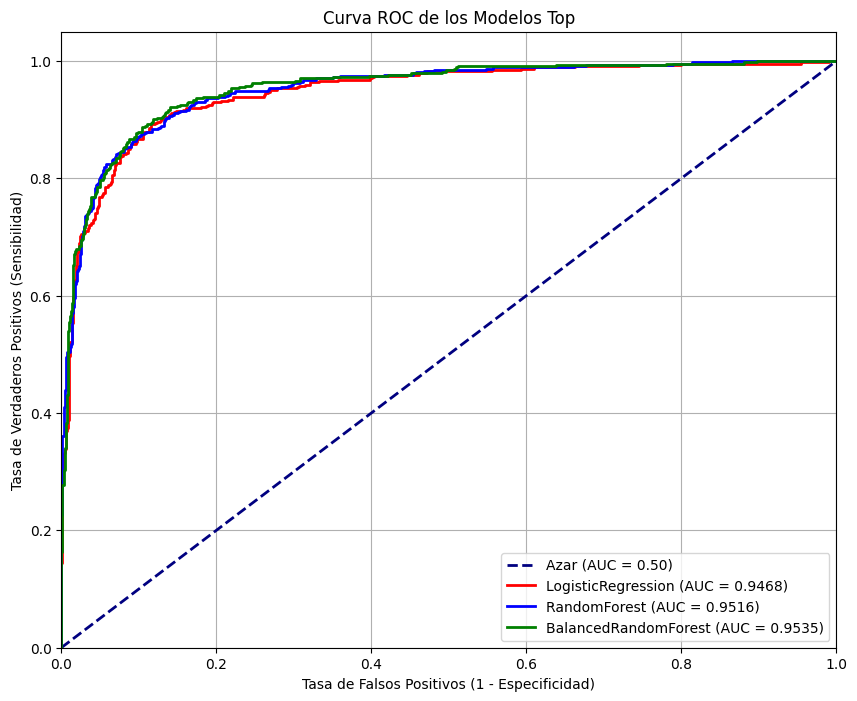

In [ ]:
top_3_names = ['RandomForest', 'BalancedRandomForest', 'LogisticRegression']

# Filtramos las claves completas de los 3 mejores modelos de acuerdo a la evidencia numerica anterior de metricas.
# Tomamos las claves en best_models son 'NombreModelo_Parametros'
top_3_keys = [k for k in best_models.keys() if k.split('_', 1)[0] in top_3_names]


# Preparar el gráfico ROC ---
plt.figure(figsize=(10, 8))
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Azar (AUC = 0.50)')
colors = cycle(['red', 'blue', 'green'])

print("========== ANÁLISIS DE RENDIMIENTO FINAL EN TEST ==========")

for key in top_3_keys:
    model_name = key.split('_', 1)[0]
    best_estimator = best_models[key]
    color = next(colors)

    y_pred_test = best_estimator.predict(X_test)

    # Try/except para modelos que no tienen predict_proba (como SVCLinear sin probability=True)
    try:
        y_proba_test = best_estimator.predict_proba(X_test)[:, 1]
    except AttributeError:
        print(f"Advertencia: {model_name} no soporta predict_proba. No se puede calcular AUC-ROC.")
        continue

    cm = confusion_matrix(y_test, y_pred_test)
    VP = cm[1, 1]
    VN = cm[0, 0]
    FP = cm[0, 1]
    FN = cm[1, 0]

    print(f"\n--- {model_name.upper()} ---")
    print(f"Matriz de Confusión:")
    print(f"Real Negativo | {VN} (VN) | {FP} (FP) |")
    print(f"Real Positivo | {FN} (FN) | {VP} (VP) |")
    print(cm)

    try:
        recall = VP / (VP + FN)
        precision = VP / (VP + FP)
        print(f"   Sensibilidad (Recall): {recall:.4f}")
        print(f"   Precisión Positiva: {precision:.4f}")
    except ZeroDivisionError:
        print("   ¡Advertencia! División por cero en métricas derivadas.")


    #AUC-ROC
    auc_score = roc_auc_score(y_test, y_proba_test)
    print(f"**AUC-ROC: {auc_score:.4f}**")

    #Generar curva ROC para el gráfico
    fpr, tpr, thresholds = roc_curve(y_test, y_proba_test)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{model_name} (AUC = {auc_score:.4f})')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
plt.ylabel('Tasa de Verdaderos Positivos (Sensibilidad)')
plt.title('Curva ROC de los Modelos Top')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# ***Calidad, Desempeño y Análisis de Resultados***
Basado en las mejores métricas obtenidas, se realizará el análisis de calidad y desempeño para los tres modelos principales: RandomForest, BalancedRandomForest, y LogisticRegression.

**Calidad y Desempeño**
Cada uno de estos tres modelos presenta métricas de calidad buenas de acuerdo a las siguientes premisas:

**Área bajo la Curva (AUC-ROC):** Los tres modelos tienen métricas por encima de 0.94, lo que indica una capacidad de discriminación buena. Aun así, BalancedRandomForest tiene el valor más alto con 0.9535. Se plantea la hipótesis de que este valor es obtenido porque este modelo permite un mejor manejo del desbalance de los datos.

**Curva ROC:** Adicionalmente, la gráfica evidencia que las líneas (curvas) tienden muy cercano hacia la esquina superior izquierda, lo que confirma una buena Sensibilidad y Especificidad en la mayoría de los umbrales. Es importante mencionar que la Sensibilidad y la *Especificidad son de suma relevancia, ya que en el contexto de mortalidad representan indicadores clave del balance entre la detección de riesgo y el control de falsas alarmas.*

Por lo anterior, y dado el contexto del proyecto, la prioridad clínica es obtener un modelo con alto rendimiento en Sensibilidad (No fallar al detectar una muerte o sea Minimizar FN), esta métrica se convierte en la más crítica. Esto, junto con la obtención de la mejor métrica de AUC-ROC (0.9535), lleva a confirmar que el mejor modelo es BalancedRandomForest.

Por último, aunque RandomForest tiene una mejor métrica de F1-Score general (0.8962), el BalancedRandomForest se considera el mejor modelo desde la perspectiva del planteamiento del problema (clínica/mortalidad) debido a su capacidad superior para detectar el riesgo. Esto se valida al observar en la Matriz de Confusión el menor número de Falsos Negativos (49) para BalancedRandomForest, que es el error de clasificación más costoso.

**Desempeño Esperado en Datos Futuros (Evidencia Numérica)**
El desempeño esperado se basa en el rendimiento del modelo BalancedRandomForest en el conjunto de prueba y se sustenta en las métricas de Recall, AUC-ROC y F1:

**Poder Predictivo:** El modelo mantendrá un buen nivel de discriminación con nuevos datos. Evidencia numérica: AUC-ROC = 0.9535.

**Generalización:** El modelo es robusto y no está sobreajustado, pues su F1-Score en Prueba (0.8898) es similar al de Entrenamiento (0.8721), mostrando una generalización efectiva.

**Error Crítico:** El modelo mantendrá un bajo nivel de Falsos Negativos. De 472 pacientes que realmente murieron (el total de la clase positiva en el conjunto de prueba), solo 49 serán clasificados erróneamente como de bajo riesgo, siendo este un valor bajo y aceptable clínicamente.

# ***En conclusión, el BalancedRandomForest mantiene un rendimiento excelente y una generalización robusta, priorizando la seguridad de los pacientes al minimizar el error crítico.***